# Disaster Tweet Detection - Naive Bayes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df=pd.read_csv(r"C:\Users\Nishant\Downloads\Disaster_Detection_Dataset.csv")

In [3]:
df

,id,keyword,location,text,tweet_length,word_count,has_hashtag,text_category
0,0,NaN,NaN,Just happened a terrible car crash,34,6,0,Short
1,2,NaN,NaN,"Heard about #earthquake is different cities, s...",64,9,1,Medium
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are...",96,19,0,Long
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires,40,4,1,Short
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan,45,8,0,Medium
...,...,...,...,...,...,...,...,...
6258,13871,ablaze,"Whoop Ass, Georgia",Not a diss song. People will take 1 thing and ...,138,28,0,Long
6259,13872,riot,San Francisco,@Riot_Sweet @jfwong @MtgoDoc @JoshLeeKwai wait...,86,14,0,Medium
6260,13873,derailed,Las Vegas,.@janeannmorrison: A former Assembly candidate...,98,11,0,Medium
6261,13874,hijack,NaN,@spencer_ellmore @CentreTransfer just wait Nor...,78,9,0,Medium


In [4]:
print("Shape:", df.shape)
df.info()
df.describe(include='all')

Shape: (6263, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6263 entries, 0 to 6262
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             6263 non-null   int64 
 1   keyword        6213 non-null   object
 2   location       4132 non-null   object
 3   text           6263 non-null   object
 4   tweet_length   6263 non-null   int64 
 5   word_count     6263 non-null   int64 
 6   has_hashtag    6263 non-null   int64 
 7   text_category  6263 non-null   object
dtypes: int64(4), object(4)
memory usage: 391.6+ KB


,id,keyword,location,text,tweet_length,word_count,has_hashtag,text_category
count,6263.000000,6213,4132,6263,6263.000000,6263.000000,6263.000000,6263
unique,NaN,221,1602,3243,NaN,NaN,NaN,3
top,NaN,demolished,New York,Wolverine Fire Update - Thursday August 6 - 9:...,NaN,NaN,NaN,Long
freq,NaN,46,74,7,NaN,NaN,NaN,3382
mean,8755.436692,NaN,NaN,NaN,102.527223,15.037362,0.251317,NaN
std,4191.293437,NaN,NaN,NaN,34.057439,5.771344,0.433805,NaN
min,0.000000,NaN,NaN,NaN,5.000000,1.000000,0.000000,NaN
25%,5276.000000,NaN,NaN,NaN,79.000000,11.000000,0.000000,NaN
50%,10388.000000,NaN,NaN,NaN,110.000000,15.000000,0.000000,NaN
75%,12309.500000,NaN,NaN,NaN,134.000000,19.000000,1.000000,NaN


In [5]:
df.isnull().sum()

id                  0
keyword            50
location         2131
text                0
tweet_length        0
word_count          0
has_hashtag         0
text_category       0
dtype: int64

In [6]:
df['keyword'] = df['keyword'].fillna('Unknown')
df['location'] = df['location'].fillna('Unknown')

# Removing null valus
df.dropna(subset=['text'], inplace=True)
print(df.isnull().sum())

id               0
keyword          0
location         0
text             0
tweet_length     0
word_count       0
has_hashtag      0
text_category    0
dtype: int64


In [7]:
df.drop_duplicates(inplace=True)
print("New Shape:", df.shape)

New Shape: (6263, 8)


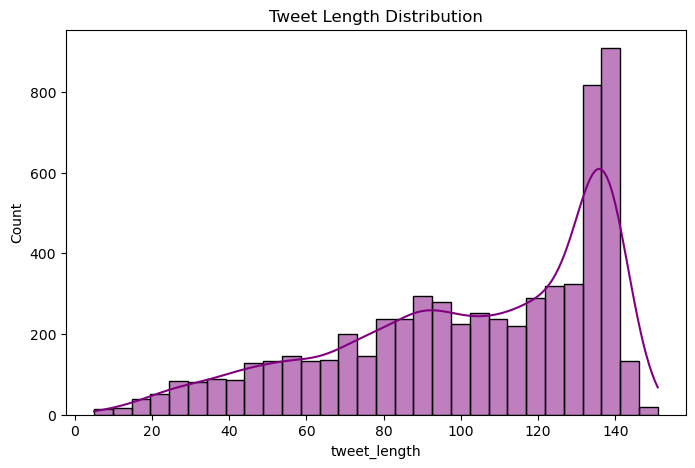

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['tweet_length'], bins=30,color="Purple", kde=True)
plt.title("Tweet Length Distribution")
plt.show()

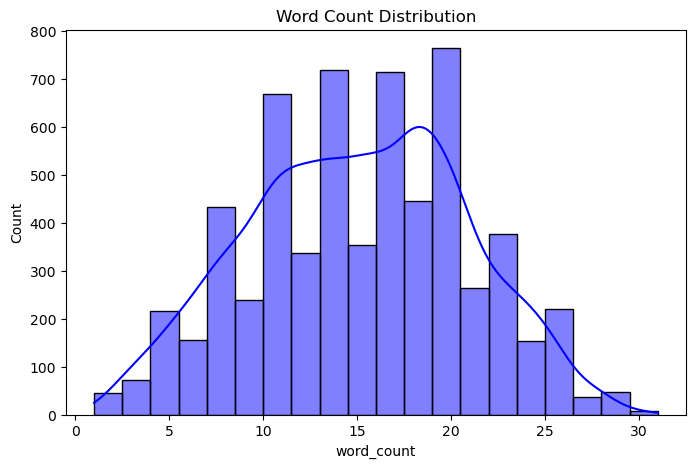

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['word_count'],color="Blue", bins=20, kde=True)
plt.title("Word Count Distribution")
plt.show()

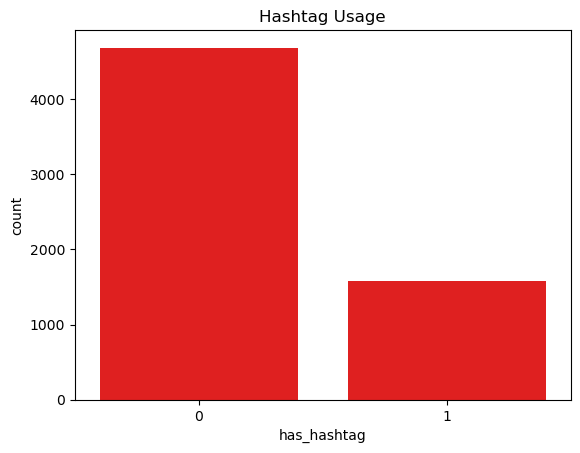

In [10]:
sns.countplot(x='has_hashtag',color="Red", data=df)
plt.title("Hashtag Usage")
plt.show()

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='text_category',color="Black", data=df)

plt.title("Text Category Distribution")
plt.show()

In [ ]:
top_keywords = df['keyword'].value_counts().head(15)
plt.figure(figsize=(10,5))
top_keywords.plot(kind='bar',color="orange")
plt.title("Top 15 Keywords")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df[['tweet_length','word_count','has_hashtag']].corr(),
    annot=True,
    cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
le = LabelEncoder()
df['target'] = le.fit_transform(df['text_category'])
print(df[['text_category','target']].head())

In [ ]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000)
X = tfidf.fit_transform(df['text'])
y = df['target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [ ]:
model = MultinomialNB()
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")

In [ ]:
print(classification_report(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
sample = ["Massive fire breaks out in city area"]
sample_vec = tfidf.transform(sample)
prediction = model.predict(sample_vec)
print("Predicted Category:",
      le.inverse_transform(prediction)[0])